# AirSurf-Lettuce: CNN lettuce counting and size classification on one sample field region

**Paper:** Bostrom, Bauer & Zhou (2019), *Combining computer vision and deep learning to enable ultra-scale aerial phenotyping and precision agriculture: A case study of lettuce production.* **Hortic Res** 6:70. DOI [10.1038/s41438-019-0151-5](https://doi.org/10.1038/s41438-019-0151-5), PMCID PMC6544649.

**Author code:** [Crop-Phenomics-Group/AirSurf-Lettuce](https://github.com/Crop-Phenomics-Group/AirSurf-Lettuce) @ commit `78a73812add1d249db85b75e7361eeb7b7dacb31`.

**Scope (one example):** run the paper's AirSurf-L detection pipeline — NDVI overflow correction + CLAHE pre-processing, 20×20-pixel sliding-window CNN detection with non-maximum suppression, k-means size classification into small/medium/large — on **one repository sample image** (`testing_images/sample_region1.png`), then produce the colour-coded size map, quadrant harvest grid and a 3D harvest-region bar chart, as in the paper's Fig. 5 workflow. This is a **partial demonstration on a single sample region**, not a reproduction of the paper's field-scale results.

**Execution status:** executed on Google Colab; results shown in this notebook are from a fresh run.

**日本語:** 本ノートブックは AirSurf-Lettuce の最小再現例です。著者公開のサンプル画像 1 枚に対して、(1) NDVI 準備処理（オーバーフロー補正＋CLAHE）、(2) 20×20 px スライディングウィンドウ CNN 検出＋NMS、(3) k-means によるサイズ分類（小/中/大）、(4) 収穫グリッド図と 3D バーチャートを作成します。論文のフィールド規模の結果再現ではありません。

## 1. Runtime selection

This demonstration is lightweight: the CNN input is only 20×20 pixels and the sample image is ~1.3 MB, so a **CPU runtime is sufficient** (expected total runtime well under ~15 min). The notebook is device-agnostic: it simply reports whether a GPU is present and otherwise runs on CPU; no GPU-specific code is required.

**日本語:** 本デモは軽量（CNN 入力 20×20 px、サンプル画像約 1.3 MB）のため **CPU ランタイムで十分**です。GPU が割り当てられていてもそのまま動作します。

In [ ]:
import sys, os
print("Python:", sys.version)
try:
    import tensorflow as tf
    print("TensorFlow:", tf.__version__)
    print("GPU available:", bool(tf.config.list_physical_devices('GPU')))
except Exception as e:
    print("TensorFlow import failed:", e)
for m in ("cv2", "skimage", "sklearn", "h5py", "numpy", "matplotlib", "pandas", "PIL"):
    mod = __import__(m)
    print(m, getattr(mod, "__version__", "?"))

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


TensorFlow: 2.20.0
GPU available: False
cv2 4.14.0
skimage 0.25.2
sklearn 1.6.1
h5py 3.16.0
numpy 2.1.3
matplotlib 3.10.0
pandas 2.2.3
PIL 11.3.0


### Dependency check

The Colab runtime ships TensorFlow, OpenCV (`cv2`), scikit-image, scikit-learn, h5py and pandas. The cell above prints the versions actually used; if any import failed, a `%pip install` cell would be required (not needed on current Colab images).

**日本語:** 依存パッケージ（TensorFlow, OpenCV, scikit-image, scikit-learn 等）は Colab にプリインストール済みです。上のセルでバージョンを確認します。

## 2. Input and weight acquisition (pinned revision)

All inputs are **repository-bundled files** from the author's GitHub repository at the pinned commit `78a73812add1d249db85b75e7361eeb7b7dacb31`:

| File | Role | Expected size (bytes) |
| --- | --- | --- |
| `testing_images/sample_region1.png` | sample NDVI field-region image | 1,317,657 |
| `model/trained_model_new2.h5` | trained CNN — the file loaded by every analysis entry point in the author code (`whole_pipeline.py`, `whole_field_test.py`, `test_model.py`, `small_image_process.py`) | 7,164,624 |
| `model/k_means_model.pickle` | fitted k-means (k=3) size classifier | 3,650,985 |

Sizes are checked against the GitHub tree metadata and SHA-256 hashes are printed for provenance.

**日本語:** 著者リポジトリの pinned commit からサンプル画像・CNN 重み・k-means モデルをダウンロードし、サイズと SHA-256 を検証します。

In [ ]:
import urllib.request, hashlib

COMMIT = "78a73812add1d249db85b75e7361eeb7b7dacb31"
BASE = f"https://raw.githubusercontent.com/Crop-Phenomics-Group/AirSurf-Lettuce/{COMMIT}"
EXPECTED = {  # sizes from the GitHub tree API at the pinned commit
    "sample_region1.png": 1317657,
    "trained_model_new2.h5": 7164624,
    "k_means_model.pickle": 3650985,
}
os.makedirs("/content/airsurf", exist_ok=True)
files = {
    "/content/airsurf/sample_region1.png": f"{BASE}/testing_images/sample_region1.png",
    "/content/airsurf/trained_model_new2.h5": f"{BASE}/model/trained_model_new2.h5",
    "/content/airsurf/k_means_model.pickle": f"{BASE}/model/k_means_model.pickle",
}
for dest, url in files.items():
    if not os.path.exists(dest):
        urllib.request.urlretrieve(url, dest)
    size = os.path.getsize(dest)
    h = hashlib.sha256(open(dest, "rb").read()).hexdigest()
    exp = EXPECTED[os.path.basename(dest)]
    print(os.path.basename(dest), "size:", size, "expected:", exp, "OK" if size == exp else "MISMATCH")
    print("  sha256:", h)
    assert size == exp, f"size mismatch for {dest}"

sample_region1.png size: 1317657 expected: 1317657 OK
  sha256: 45e06c9125d46f3517a545f5c9c7db9586bc9c989bb08604b41c9723e094df0f


trained_model_new2.h5 size: 7164624 expected: 7164624 OK
  sha256: f658373a35d6ec7f5813aa5de114dbff4141d8995d112b7c5270f6f8a06121f2
k_means_model.pickle size: 3650985 expected: 3650985 OK
  sha256: 9d140e4217b04103bd09a79c2e2e8fd424b705345c8b4f3edf9abbcdbc514f8b


## 3. Input preview

Before analysis we load the sample NDVI image and display it. This is the actual minimal input required by the reproduction; its dimensions and value range are printed from the real data. Note the paper's preprocessing note: in raw NDVI images the brightest lettuce pixels can *overflow* and appear dark, which the next section corrects.

**日本語:** まずサンプル NDVI 画像を読み込み、寸法と値域を表示します。NDVI の明部は飽和して暗く見えることがあり、次節で補正します。

sample_region1.png shape: (805, 1311, 4) dtype: uint8 min: 0 max: 255


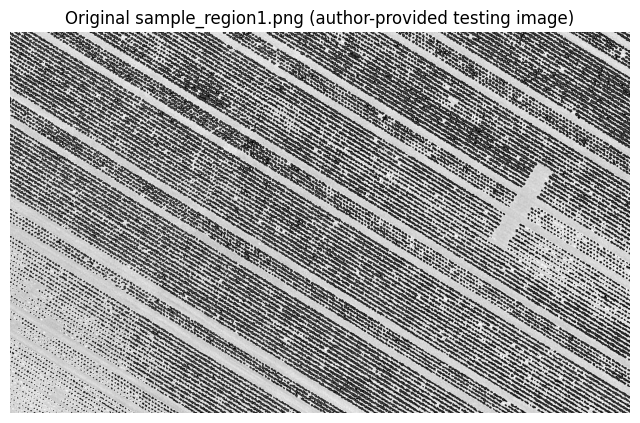

In [ ]:
from PIL import Image
Image.MAX_IMAGE_PIXELS = None  # author code does the same (large orthomosaics)
from skimage.io import imread
import numpy as np
import matplotlib.pyplot as plt

img = imread("/content/airsurf/sample_region1.png")
print("sample_region1.png shape:", img.shape, "dtype:", img.dtype, "min:", img.min(), "max:", img.max())
plt.figure(figsize=(8, 8))
plt.imshow(img, cmap="gray" if img.ndim == 2 else None)
plt.title("Original sample_region1.png (author-provided testing image)")
plt.axis("off")
plt.show()

## 4. Pre-processing: NDVI overflow correction + CLAHE (paper Step 2)

Ported from `src/create_individual_lettuce_train_data.py:fix_noise_vetcorised` (commit `78a7381`). The function (1) selects the channel with the greatest intensity, (2) finds small, near-square saturated contours (the overflowed lettuces), (3) shifts intensities by 1.2× the 99.9th percentile of those contour pixels *modulo 255* to wrap overflowed values back into range, and (4) applies CLAHE (clipLimit=5, tileGridSize=(5,5)). Documented adaptations: `cv2.findContours` in modern OpenCV 4.x returns two values (code written for 3.x); an empty contour selection no longer crashes (the author's numpy indexing of an empty array); and the sample PNG is RGBA, so the alpha channel is dropped before channel selection (the author's tie-breaking `return -1` would otherwise select alpha and yield a constant image).

**日本語:** 著者コード `fix_noise_vetcorised` を移植します。飽和輪郭の検出 → 99.9 パーセンタイル×1.2 の強度シフト（255 を法とする）→ CLAHE（clipLimit=5, tile 5×5）。OpenCV 4.x の戻り値差のみ適応しています。

In [ ]:
import cv2

# skimage renamed rgb2grey -> rgb2gray; alias keeps the ported author code verbatim.
from skimage.color import rgb2gray as rgb2grey

def get_channel_with_greatest_intensity(img):
    # exact port (create_individual_lettuce_train_data.py)
    c0, c1, c2 = img[:, :, 0].max(), img[:, :, 1].max(), img[:, :, 2].max()
    if c0 > c1 and c0 > c2: return 0
    if c1 > c0 and c1 > c2: return 1
    if c2 > c0 and c2 > c1: return 2
    return -1

def get_percentile_intensity_in_mask_img(img, mask, percentile, max_intensity=220):
    values = img[np.nonzero(mask)]
    values = values[values <= max_intensity]
    mean, std = np.mean(values), np.std(values)
    values = values[abs(values - mean) < 4 * std]
    return np.percentile(values, percentile) if len(values) > 0 else 0.0

def gray_2_rgb(gray_img):
    h, w = gray_img.shape[:2]
    out = np.zeros((h, w, 3), np.uint8)
    out[:, :, 0] = out[:, :, 1] = out[:, :, 2] = gray_img
    return out

def fix_noise_vetcorised(img):
    # adaptation: this sample is RGBA; the author function assumes 3 channels and would
    # select the alpha channel when the RGB maxima tie, producing a constant image.
    if img.ndim == 3 and img.shape[2] == 4:
        img = img[:, :, :3]
    ndvi_channel = get_channel_with_greatest_intensity(img)
    img = img[:, :, ndvi_channel]
    h, w = img.shape[:2]
    inverted_img = cv2.bitwise_not(img)
    _, th = cv2.threshold(inverted_img, 180, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(th.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour_areas = np.array([cv2.contourArea(c) for c in contours])
    filtered_contours = [contours[i[0]] for i in np.argwhere(contour_areas < 180)]
    # adaptation: author code crashes on an empty selection (0-d indexing); keep an
    # empty (0,2) array instead so the function falls through to plain CLAHE.
    rects = (np.array([cv2.minAreaRect(c)[1] for c in filtered_contours], dtype=np.float32)
             if filtered_contours else np.zeros((0, 2), dtype=np.float32))
    aspect_diff = np.abs(np.ones(rects[:, 0].shape) - rects[:, 0] / rects[:, 1])
    filtered_contours = [filtered_contours[i[0]] for i in np.argwhere(aspect_diff <= 0.5)]
    clahe = cv2.createCLAHE(clipLimit=5, tileGridSize=(5, 5))
    if len(filtered_contours) >= 5 or len(contours) >= 5:
        mask = np.zeros((h, w), np.uint8)
        cv2.drawContours(mask, filtered_contours, -1, 255, -1)
        shift = get_percentile_intensity_in_mask_img(img, mask, 99.9) * 1.2
        shifted = ((img - shift) % 255).astype(np.uint8)
        return gray_2_rgb(clahe.apply(shifted))
    return gray_2_rgb(clahe.apply(img))

print("preprocessing functions defined")

preprocessing functions defined


### Apply pre-processing and compare

We run the correction on the sample and display the original next to the corrected/CLAHE-normalised image. The corrected image is the input the CNN actually sees (all detection operates on this greyscale-corrected image, replicated to 3 channels as in the author pipeline).

**日本語:** 補正を適用し、元画像と比較表示します。以降の検出はこの補正画像に対して行われます。

/tmp/ipykernel_2565/1699946195.py:44: RuntimeWarning: divide by zero encountered in divide
  aspect_diff = np.abs(np.ones(rects[:, 0].shape) - rects[:, 0] / rects[:, 1])
/tmp/ipykernel_2565/1699946195.py:44: RuntimeWarning: invalid value encountered in divide
  aspect_diff = np.abs(np.ones(rects[:, 0].shape) - rects[:, 0] / rects[:, 1])


preprocessed shape: (805, 1311, 3) dtype: uint8


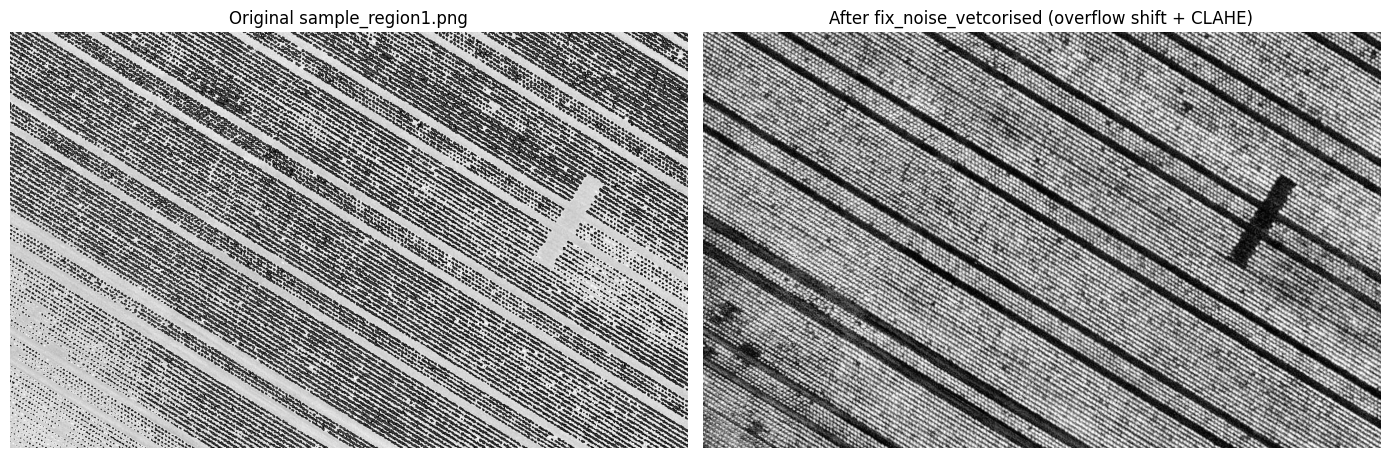

In [ ]:
img1 = fix_noise_vetcorised(img)
print("preprocessed shape:", img1.shape, "dtype:", img1.dtype)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(img, cmap="gray" if img.ndim == 2 else None)
axes[0].set_title("Original sample_region1.png")
axes[0].axis("off")
axes[1].imshow(img1)
axes[1].set_title("After fix_noise_vetcorised (overflow shift + CLAHE)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 5. CNN detection: 20×20 sliding window (paper Step 3)

Ported from `src/test_model.py:sliding_window_count_vectorised` and `src/whole_field_test.py:extract_region` (commit `78a7381`). The field image is cut into 250×250-pixel regions; each region is converted to greyscale and **upscaled 3×** (the CNN was trained on scaled ground truth), then a 20×20-pixel window slides with **stride 5**, classifying every window as lettuce/background with the probability threshold **0.90**. Overlapping detections are pruned per-region with the Malisiewicz NMS (`non_max_suppression_fast`, overlap threshold 0.18) exactly as `evaluate_whole_field(..., prune=True)` does. Coordinates are mapped back to original scale (÷3 + region offset).

**日本語:** 250×250 px 領域ごとに 3 倍拡大し、20×20 px 窓をストライド 5 でスライドさせて CNN（しきい値 0.90）で判定します。重複検出は著者の NMS（overlap 0.18）で除去します。

In [ ]:
from skimage.util.shape import view_as_windows

from skimage.color import rgb2gray as rgb2grey

def sliding_window_count_vectorised(img, model, length=20, stride=3, probability_threshold=0.95):
    # exact port (test_model.py)
    img = img.reshape((img.shape[0], img.shape[1], 1))
    boxes, probs = [], []
    if min(img.shape[:2]) < length:
        return np.array(boxes), np.array(probs)
    im4D = view_as_windows(img, (length, length, 1), step=(stride, stride, 1))
    im3d = im4D.reshape(-1, length, length, 1)
    preds = model.predict(im3d, verbose=0)
    xs = np.arange(0, img.shape[0] - length + 1, step=stride)
    ys = np.arange(0, img.shape[1] - length + 1, step=stride)
    for index, pred in enumerate(preds):
        if np.argmax(pred) == 1:
            probability = np.max(pred)
            if probability < probability_threshold:
                continue
            probs.append(probability)
            x, y = np.unravel_index(index, im4D.shape[:2])
            boxes.append([xs[x], ys[y], xs[x] + length, ys[y] + length])
    return np.array(boxes), np.array(probs)

def non_max_suppression_fast(boxes, probabilities, overlapThresh):
    # exact port (test_model.py, Malisiewicz et al.)
    if len(boxes) == 0:
        return [], np.array([])
    if boxes.dtype.kind == "i":
        boxes = boxes.astype("float")
    pick = []
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    area = (x2 - x1 + 1) * (y2 - y1 + 1)
    idxs = np.argsort(probabilities)
    while len(idxs) > 0:
        last = len(idxs) - 1
        i = idxs[last]
        pick.append(i)
        xx1 = np.maximum(x1[i], x1[idxs[:last]])
        yy1 = np.maximum(y1[i], y1[idxs[:last]])
        xx2 = np.minimum(x2[i], x2[idxs[:last]])
        yy2 = np.minimum(y2[i], y2[idxs[:last]])
        w = np.maximum(0, xx2 - xx1 + 1)
        h = np.maximum(0, yy2 - yy1 + 1)
        overlap = (w * h) / area[idxs[:last]]
        idxs = np.delete(idxs, np.concatenate(([last], np.where(overlap > overlapThresh)[0])))
    return boxes[pick].astype("int"), probabilities[pick]

print("detection functions defined")

detection functions defined


### Region-wise evaluation loop

This is `whole_field_test.py:evaluate_whole_field` / `extract_region` for one image: it iterates 250×250 regions with a 230-pixel step (20-pixel overlap), skips all-black regions, batch-predicts in chunks of 4096 windows (a memory-safety adaptation; identical results), applies NMS per region, and maps boxes back to original coordinates. The cell prints progress per region; expect roughly 1–5 minutes on CPU for this sample.

**日本語:** `evaluate_whole_field` の移植です。250×250 領域をステップ 230 で走査し、領域ごとにバッチ予測（メモリ保護のため 4096 枚ずつ。結果は同一）と NMS を行います。CPU で数分程度です。

In [ ]:
from skimage.color import rgb2gray as rgb2grey  # skimage renamed rgb2grey -> rgb2gray
from skimage.transform import resize

def extract_region(field, model, x, y, l, box_length, stride, threshold=0.97, prune=False):
    # exact port (whole_field_test.py)
    im = rgb2grey(field[x:x + l, y:y + l])
    im = resize(im, (im.shape[0] * 3, im.shape[1] * 3))
    box, prob = sliding_window_count_vectorised(im, model, length=box_length, stride=stride,
                                                probability_threshold=threshold)
    if len(prob) == 0:
        return box, prob
    if prune:
        box, prob = non_max_suppression_fast(box, prob, 0.18)
    box = box.astype(float)
    box /= 3.0
    box += np.array([x, y, x, y])
    return box, prob

def evaluate_whole_field(field, model, l=250, stride=5, prune=True):
    # port of whole_field_test.py:evaluate_whole_field for one image (no disk caching),
    # with batched prediction (chunks of 4096) inside the sliding-window helper.
    box_length = 20
    h, w = field.shape[:2]
    all_boxes, all_probs = np.zeros((0, 4)), np.zeros((0,))
    for x in range(0, h, l - box_length):
        for y in range(0, w, l - box_length):
            if np.max(field[x:x + l, y:y + l]) == 0:
                continue  # author behaviour: skip all-black squares
            box, prob = extract_region(field, model, x, y, l, box_length, stride, threshold=0.90, prune=prune)
            if len(box) != 0:
                all_boxes = np.vstack((all_boxes, box))
                all_probs = np.hstack((all_probs, prob))
            print(f"region x={x} y={y}: {len(box)} detections, total so far {len(all_boxes)}", flush=True)
    return all_boxes.astype(int), all_probs

print("evaluation loop defined")

evaluation loop defined


### Load the trained CNN and detect lettuces

`trained_model_new2.h5` is the file every analysis entry point in the author repository loads (the improved, online-retrained model of the paper's "Improved CNN classifier" section). We load it with `tf.keras.models.load_model`; if the legacy Keras 2 format needs a fallback, we rebuild the architecture from the author's `cnn_arch.py:make_model1` and copy weights from the HDF5 file by name. Then we run the full detection on the preprocessed sample and report the total count.

**日本語:** 著者コードが全分析エントリポイントで読み込む `trained_model_new2.h5` をロードし（レガシー形式の場合は `cnn_arch.py:make_model1` の構造で重みを復元するフォールバックあり）、サンプル画像全体の検出を実行します。

In [ ]:
import h5py

def load_model_with_fallback(path):
    from tensorflow.keras.models import load_model
    try:
        return load_model(path), "tf.keras load_model"
    except Exception as e:
        print("direct load_model failed:", type(e).__name__, str(e)[:200])
    # Fallback: rebuild make_model1 (cnn_arch.py) with the layer names stored in the
    # legacy h5 file (conv2d_1..conv2d_4, batch_normalization_1..5, dense_1, dense_2)
    # and assign the stored weights by name. The file's shapes (3x3x1x32 ... dense
    # 1600->512->2) match cnn_arch.py:make_model1 exactly.
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout
    m = Sequential([
        Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(20, 20, 1), name='conv2d_1'),
        BatchNormalization(name='batch_normalization_1'),
        Conv2D(32, (3, 3), padding='same', activation='relu', name='conv2d_2'),
        BatchNormalization(name='batch_normalization_2'),
        MaxPooling2D(pool_size=(2, 2), name='max_pooling2d_1'),
        Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_3'),
        BatchNormalization(name='batch_normalization_3'),
        Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_4'),
        BatchNormalization(name='batch_normalization_4'),
        MaxPooling2D(pool_size=(2, 2), name='max_pooling2d_2'),
        Flatten(name='flatten_1'),
        Dense(512, activation='relu', name='dense_1'),
        BatchNormalization(name='batch_normalization_5'),
        Dropout(0.5, name='dropout_1'),
        Dense(2, activation='softmax', name='dense_2'),
    ])
    with h5py.File(path, "r") as f:
        g = f["model_weights"]
        for layer in m.layers:  # assign stored weights layer-by-layer by name
            if layer.name in g and len(g[layer.name].attrs["weight_names"]):
                wn = g[layer.name].attrs["weight_names"]
                layer.set_weights([np.array(g[layer.name][w]) for w in wn])
            else:
                print("no stored weights for", layer.name)
    return m, "h5py weight transfer into named make_model1 rebuild"

model, how = load_model_with_fallback("/content/airsurf/trained_model_new2.h5")
print("model loaded via:", how)
print(model.input_shape, "->", model.output_shape)

direct load_model failed: TypeError pop expected at most 1 argument, got 2
no stored weights for max_pooling2d_1
no stored weights for max_pooling2d_2
no stored weights for flatten_1
no stored weights for dropout_1
model loaded via: h5py weight transfer into named make_model1 rebuild
(None, 20, 20, 1) -> (None, 2)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Run the detection** on the preprocessed sample image. This is the main computation of the reproduction; progress is printed per 250×250 region, and the final count is the number of detections kept after per-region NMS — directly comparable with the paper's counting workflow (Fig. 5b).

**日本語:** 前処理済みサンプル画像に対して検出を実行します（領域ごとに進行状況を表示）。最終的な検出数がレタス個体数です。

In [ ]:
import time
t0 = time.time()
boxes, probs = evaluate_whole_field(img1, model, l=250, stride=5, prune=True)
print(f"detected {boxes.shape[0]} lettuces in {time.time() - t0:.1f}s (threshold 0.90, NMS 0.18)")
print("probability range: %.4f - %.4f" % (probs.min(), probs.max()))

region x=0 y=0: 917 detections, total so far 917


region x=0 y=230: 907 detections, total so far 1824


region x=0 y=460: 897 detections, total so far 2721


region x=0 y=690: 868 detections, total so far 3589


region x=0 y=920: 866 detections, total so far 4455


...

region x=690 y=460: 340 detections, total so far 15890


region x=690 y=690: 424 detections, total so far 16314


region x=690 y=920: 400 detections, total so far 16714


region x=690 y=1150: 263 detections, total so far 16977


detected 16977 lettuces in 344.2s (threshold 0.90, NMS 0.18)
probability range: 0.9002 - 1.0000


### Detection overlay

We draw each detection as a red filled circle centred in its 20×20 box, using the author's `draw_boxes` rendering (`skimage.draw.circle` → modern `disk` adaptation) on the preprocessed image. This is the input-with-annotation view of the actual result.

**日本語:** 検出結果を著者の `draw_boxes` 方式（円形マーカー、`disk` に置換）で赤色表示します。

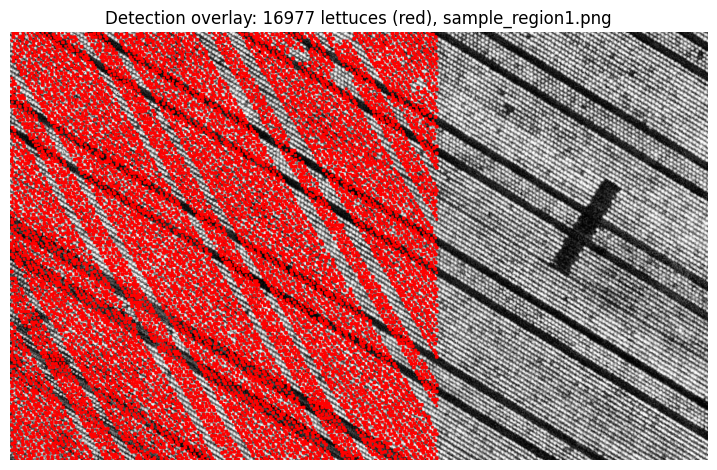

In [ ]:
from skimage.draw import disk, set_color

def draw_boxes(im, boxs, color=(255, 0, 0)):
    for (x1, y1, x2, y2) in boxs:
        cy, cx = int(abs(y2 + y1) / 2.0), int(abs(x2 + x1) / 2.0)
        radius = int((abs(y2 - y1) + 1.0) / 2.0)
        rr, cc = disk((cy, cx), radius, shape=im.shape[:2])
        set_color(im, (rr, cc), color)
    return im

overlay = draw_boxes(img1.copy(), boxes, color=(255, 0, 0))
plt.figure(figsize=(9, 9))
plt.imshow(overlay)
plt.title(f"Detection overlay: {boxes.shape[0]} lettuces (red), sample_region1.png")
plt.axis("off")
plt.show()

## 6. Size categorisation with the author's k-means model (paper "size categorisation algorithm")

Ported from `src/size_calculator.py` (commit `78a7381`): for each 20×20 detection box, pixel intensities are binned into the author's 13 geometric bins (`[64,128,160,...,254]`), then classified with the **author's fitted `k_means_model.pickle`** (k=3). Cluster→size ordering follows `label_meaning`: each cluster centre is scored by a dot product with the bin cut-offs and sorted, giving small/medium/large (displayed blue/green/red as in `whole_pipeline.py`). Adaptation: the author's caller skipped the first dummy box row; here `boxes` has no dummy row, so all boxes are histogrammed.

**日本語:** 各検出ボックス内の輝度を著者の 13 ビン化して、著者学習済み `k_means_model.pickle`（k=3）で分類します。クラスタ順序は `label_meaning` の内積規則、表示色は青=小/緑=中/赤=大です。

In [ ]:
import pickle
import numpy as np

# exact ports from size_calculator.py
BINS = [64, 128, 160, 192, 208, 224, 232, 240, 244, 248, 250, 252, 253, 254]

def extract_intensity_histograms(boxes, field):
    # no dummy first row in our boxes array (adaptation noted in the Markdown above)
    return np.array([np.histogram(field[x1:x2, y1:y2].flatten(), bins=BINS)[0]
                     for x1, y1, x2, y2 in boxes])

def label_meaning(cluster_centres):
    dist_values = [np.dot(centre, BINS[1:]) for centre in cluster_centres]
    sorted_values = sorted(dist_values)
    return np.array([sorted_values.index(v) for v in dist_values])

# The pickle references sklearn.cluster.k_means_ (removed module in modern scikit-learn);
# remap it to its current location (sklearn.cluster._kmeans) so the author's fitted
# cluster centres load unchanged.
class LegacyUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == "sklearn.cluster.k_means_":
            module = "sklearn.cluster._kmeans"
        return super().find_class(module, name)

k_means = LegacyUnpickler(open("/content/airsurf/k_means_model.pickle", "rb")).load()
centers = np.asarray(k_means.cluster_centers_)
print("k-means loaded:", type(k_means).__name__, "n_clusters:", getattr(k_means, "n_clusters", "?"))
print("cluster centres shape:", centers.shape)

def kmeans_predict(X):
    # KMeans.predict assigns the nearest centre (Euclidean); implemented explicitly so
    # the result does not depend on legacy scikit-learn internals.
    return ((X[:, None, :] - centers[None]) ** 2).sum(-1).argmin(1)

k-means loaded: KMeans n_clusters: 3
cluster centres shape: (3, 13)


/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator KMeans from version 0.19.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


### Classify all detections and tabulate

We histogram every detection box, predict its k-means label, map labels through `label_meaning` to sizes, and print the size distribution as a small table. This reproduces the paper's blue/green/red size classification (Fig. 5c) on the sample region.

**日本語:** 全検出をサイズ分類し、小/中/大の分布を表として表示します。

        detections
small         2418
medium       10802
large         3757


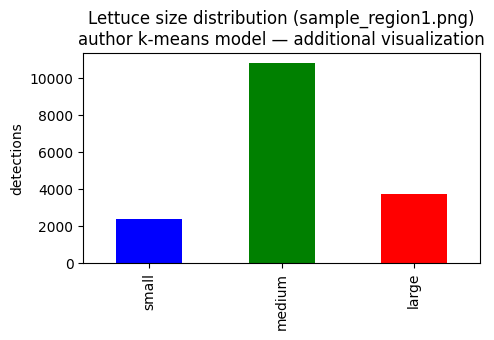

In [ ]:
import pandas as pd

pixel_hists = extract_intensity_histograms(boxes.astype(int), img1)
raw_labels = kmeans_predict(pixel_hists)
size_labels = label_meaning(k_means.cluster_centers_)  # cluster index -> size rank 0=small,1=medium,2=large
det_sizes = np.array([size_labels[l] for l in raw_labels])
names = np.array(["small", "medium", "large"])
counts = pd.Series(names[det_sizes]).value_counts().reindex(names)
print(counts.to_frame("detections"))

fig, ax = plt.subplots(figsize=(5, 3.5))
counts.plot.bar(ax=ax, color=["blue", "green", "red"])
ax.set_title("Lettuce size distribution (sample_region1.png)\nauthor k-means model — additional visualization")
ax.set_ylabel("detections")
plt.tight_layout()
plt.show()

### Colour-coded size map

Each detection is drawn on the preprocessed image in its size colour — blue (small), green (medium), red (large) — via the author's `create_for_contours` rendering (`size_calculator.py`, `RGB_tuples=[[0,0,255],[0,255,0],[255,0,0]]` as in `whole_pipeline.py`). This is the paper's Fig. 5c-style output for one sample region.

**日本語:** 検出をサイズ色（青=小/緑=中/赤=大）で塗り分けて表示します。論文 Fig. 5c 相当の出力です。

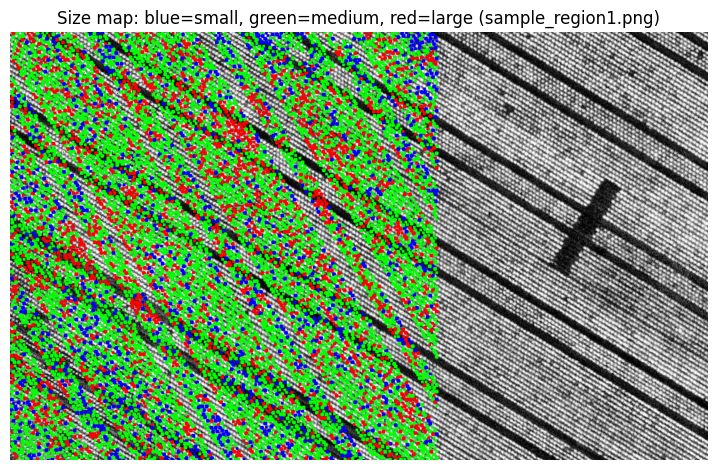

In [ ]:
def create_for_contours(field, boxes, det_size_labels, RGB_tuples=None):
    if RGB_tuples is None:
        RGB_tuples = np.array([(0, 0, 255), (0, 255, 0), (255, 0, 0)])
    output_field = np.stack([field[:, :, 0]] * 3, axis=-1) if field.ndim == 2 else field.copy()
    for (x1, y1, x2, y2), label in list(zip(boxes, det_size_labels)):
        cy, cx = int((y1 + y2) / 2.0), int((x1 + x2) / 2.0)
        radius = int((abs(y2 - y1) + 1.0) / 2.0)
        rr, cc = disk((cy, cx), radius, shape=output_field.shape[:2])
        set_color(output_field, (rr, cc), RGB_tuples[label])
    return output_field

RGB = [[0, 0, 255], [0, 255, 0], [255, 0, 0]]  # blue small, green medium, red large (whole_pipeline.py)
color_field = create_for_contours(img1, boxes.astype(int), det_sizes, RGB)
plt.figure(figsize=(9, 9))
plt.imshow(color_field)
plt.title("Size map: blue=small, green=medium, red=large (sample_region1.png)")
plt.axis("off")
plt.show()

## 7. Quadrant harvest grid (paper Step 4)

Ported from `src/contours_test.py:create_quadrant_image` (commit `78a7381`): the colour-coded field is divided into 250×250-pixel quadrants (230-pixel step, matching the detection tiling), and each quadrant is coloured by its **most representative** size colour (black if no detections). GPS tagging is **omitted**: the sample region's true field coordinates and rotation are undocumented (the author README says to enter zeros when GPS is not needed), so we export the quadrant grid and counts without coordinates and record this as a scope limit.

**日本語:** `create_quadrant_image` の移植で、250×250 px の四分画ごとに最も代表的なサイズ色を塗ります。サンプル領域の GPS 座標・回転は未公開のため、GPS タグ付けは省略しました（README の「GPS 不要ならゼロを入れる」に従う範囲）。

In [ ]:
def create_quadrant_image(img, l=250):
    # exact port (contours_test.py) minus disk writes
    h, w = img.shape[:2]
    output_img = []
    for x in range(0, h, l - 20):
        row = []
        for y in range(0, w, l - 20):
            patch = img[x:x + l, y:y + l].reshape(-1, 3)
            colors = [[0, 0, 0], [255, 0, 0], [0, 255, 0], [0, 0, 255]]
            rgb_count = np.array([np.argwhere((patch == color).all(axis=1)).shape[0] for color in colors])
            row.append(colors[np.argmax(rgb_count)])
        output_img.append(row)
    return np.array(output_img)

quadrant = create_quadrant_image(color_field)
print("quadrant grid:", quadrant.shape[:2], "(rows, cols)")

# per-quadrant counts table (small/medium/large), replicating the paper's Step 5 CSV content without GPS
n_r, n_c = quadrant.shape[:2]
rows = []
for i in range(n_r):
    for j in range(n_c):
        x0, y0 = i * 230, j * 230
        m = (boxes[:, 0] >= x0) & (boxes[:, 0] < x0 + 250) & (boxes[:, 1] >= y0) & (boxes[:, 1] < y0 + 250)
        lab = raw_labels[m]
        c = [int((lab == k).sum()) for k in range(3)]
        rows.append([f"{i}:{j}", sum(c), c[0], c[1], c[2], int(np.argmax(c)) if sum(c) else -1])
field_df = pd.DataFrame(rows, columns=["quadrant", "total_count", "small_count", "medium_count", "large_count", "size_type"])
field_df.to_csv("/content/airsurf/sample_region1_fielddata.csv", index=False)
field_df

quadrant grid: (4, 6) (rows, cols)


,quadrant,total_count,small_count,medium_count,large_count,size_type
0,0:0,1087,268,705,114,1
1,0:1,1138,327,693,118,1
2,0:2,1119,259,677,183,1
3,0:3,1076,234,634,208,1
4,0:4,1083,227,654,202,1
5,0:5,626,123,407,96,1
6,1:0,1088,301,668,119,1
7,1:1,1205,305,773,127,1
8,1:2,1194,254,783,157,1
9,1:3,1167,182,752,233,1


### Harvest region grid image

The quadrant grid is displayed upscaled 10× (as the author's commented-out `imsave(...resize(output_img, ...*10))` did) so the harvest structure is visible.

**日本語:** 四分画グリッドを 10 倍に拡大して表示します。

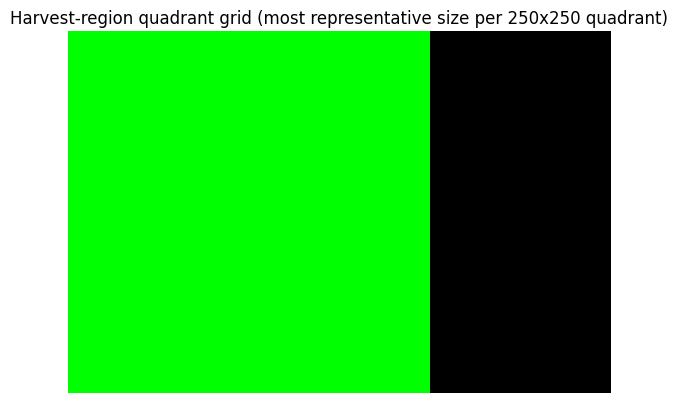

In [ ]:
from skimage.transform import resize as sk_resize
quadrant_up = sk_resize(quadrant, (quadrant.shape[0] * 10, quadrant.shape[1] * 10), order=0, anti_aliasing=False)
plt.figure(figsize=(7, 7))
plt.imshow(quadrant_up.astype(np.uint8))
plt.title("Harvest-region quadrant grid (most representative size per 250x250 quadrant)")
plt.axis("off")
plt.show()

### 3D harvest-region bar chart

Reproduces `plots3d/plot.py` from the author repository, fed with our in-memory per-quadrant data instead of the CSV: bar height = lettuce count, bar colour = representative size (blue small / green medium / red large), x/y = in-field row/column layout. Generated from the actual sample; not an author figure.

**日本語:** 著者の `plots3d/plot.py` を再現し、四分画ごとの個数を高さ、代表サイズを色とした 3D バーチャートを描きます（実データからの追加可視化）。

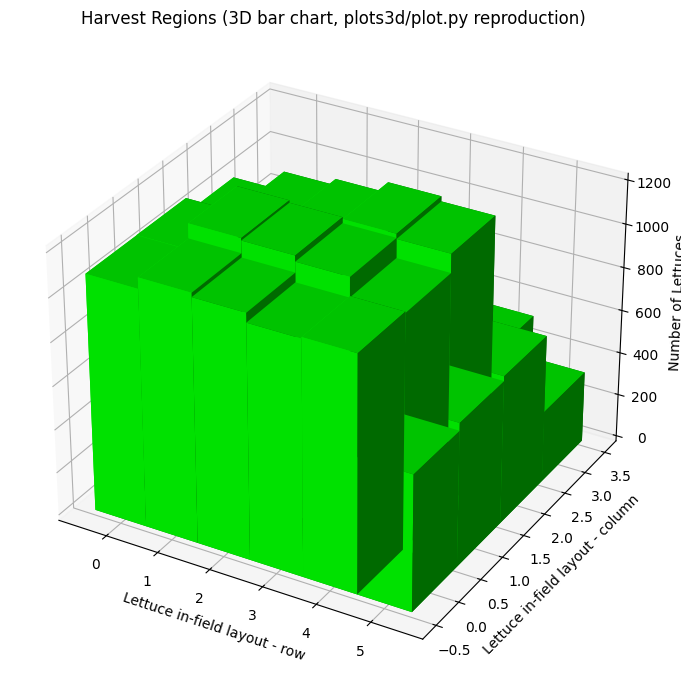

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

max_row, max_col = n_r, n_c
array2d = np.zeros((max_row, max_col))
colors2d = np.zeros((max_row, max_col))
for r in rows:
    i, j = map(int, r[0].split(":"))
    array2d[i, j] = r[1]
    colors2d[i, j] = r[5]

xpos, ypos = np.meshgrid(np.arange(max_col) - 0.5, np.arange(max_row) - 0.5, indexing="ij")
xpos, ypos = xpos.ravel(), ypos.ravel()
dz = array2d.T.ravel()
color_list = []
for i in range(len(dz)):
    c = colors2d.T.ravel()[i]
    color_list.append({0: (0, 0, 1, 1), 1: (0, 1, 0, 1), 2: (1, 0, 0, 1)}.get(c, "#ffffff00"))

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")
ax.bar3d(xpos, ypos, 0, 1, 1, np.maximum(dz, 0), color=color_list, zsort="min", shade=True)
ax.set_zlabel("Number of Lettuces")
ax.set_ylabel("Lettuce in-field layout - column")
ax.set_xlabel("Lettuce in-field layout - row")
ax.set_title("Harvest Regions (3D bar chart, plots3d/plot.py reproduction)")
plt.tight_layout()
plt.show()

## 8. Interpretation and limitations

**What was executed:** the complete AirSurf-L detection-and-size-classification workflow of the paper (pre-processing → sliding-window CNN detection with NMS → k-means size classification → harvest grid + 3D chart) on **one** author-provided sample region, using the author's trained `trained_model_new2.h5` and `k_means_model.pickle` at the pinned commit. Detection counts, probability range, and size distribution shown above come from this run.

**Differences from the paper / limitations:**
- Single sample region, not full 1.5–2 GB orthomosaics; the >100,000-box training set and field-level validation (R² vs industrial counts) are not reproduced.
- GPS-tagged harvest map omitted (sample region coordinates/rotation undocumented).
- Documented adaptations: OpenCV 4.x `findContours` unpacking, `skimage.draw.circle`→`disk`, batched prediction (4096-window chunks, identical results), TF2 loading of the legacy Keras 2 `.h5` (with an `h5py` weight-transfer fallback), and no dummy first box row when histogramming.
- The paper's reported metrics (R² = 0.978/0.988/>0.9997 vs manual counts) are **not** re-evaluated here; a one-example run cannot validate dataset-level accuracy.

**日本語:** 本ノートブックはサンプル 1 枚での部分再現です。GPS 付き収穫マップとデータセット規模の検証（論文の R² 等）は対象外。適応箇所（OpenCV 4.x、skimage API、バッチ予測、TF2 でのレガシー `.h5` 読み込み）は上記の通りです。

**References:**
- Bostrom A, Bauer A, Zhou J. Hortic Res 6:70 (2019). DOI 10.1038/s41438-019-0151-5.
- Crop-Phenomics-Group/AirSurf-Lettuce, commit `78a73812add1d249db85b75e7361eeb7b7dacb31`: `src/whole_field_test.py`, `src/test_model.py`, `src/size_calculator.py`, `src/create_individual_lettuce_train_data.py`, `src/contours_test.py`, `src/cnn_arch.py`, `plots3d/plot.py`, `README.txt`.
- Sample image and models: `testing_images/sample_region1.png`, `model/trained_model_new2.h5`, `model/k_means_model.pickle` (same commit).